<a href="https://colab.research.google.com/github/Zekeriya-Ui/Zekeriya-Ui/blob/main/Mushroom_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub
path = kagglehub.dataset_download("uciml/mushroom-classification")

100%|██████████| 34.2k/34.2k [00:00<00:00, 42.6MB/s]

Extracting files...


In [4]:
import os
import pandas as pd
import kagglehub

def main():
    # 1. Download the latest version of the dataset
    print("Downloading dataset from Kaggle...")
    dataset_path = kagglehub.dataset_download("uciml/mushroom-classification")

    print(f"\nDataset downloaded successfully to:")
    print(dataset_path)

    # 2. Inspect the downloaded files
    print("\nFiles in dataset directory:")
    files = os.listdir(dataset_path)
    for file in files:
        print(f" - {file}")

    # 3. Load the primary dataset file (mushrooms.csv)
    csv_file_name = "mushrooms.csv"
    csv_path = os.path.join(dataset_path, csv_file_name)

    if os.path.exists(csv_path):
        print(f"\nLoading '{csv_file_name}' into pandas DataFrame...")
        df = pd.read_csv(csv_path)

        # Display basic information about the dataset
        print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
        print("First 5 rows:")
        print(df.head())
    else:
        print(f"\nFile '{csv_file_name}' not found in the downloaded directory.")

if __name__ == "__main__":
    main()

Using Colab cache for faster access to the 'mushroom-classification' dataset.

Dataset downloaded successfully to:
/kaggle/input/mushroom-classification

Files in dataset directory:
 - mushrooms.csv

Loading 'mushrooms.csv' into pandas DataFrame...
Dataset Shape: 8124 rows, 23 columns

First 5 rows:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                   

Using Colab cache for faster access to the 'mushroom-classification' dataset.


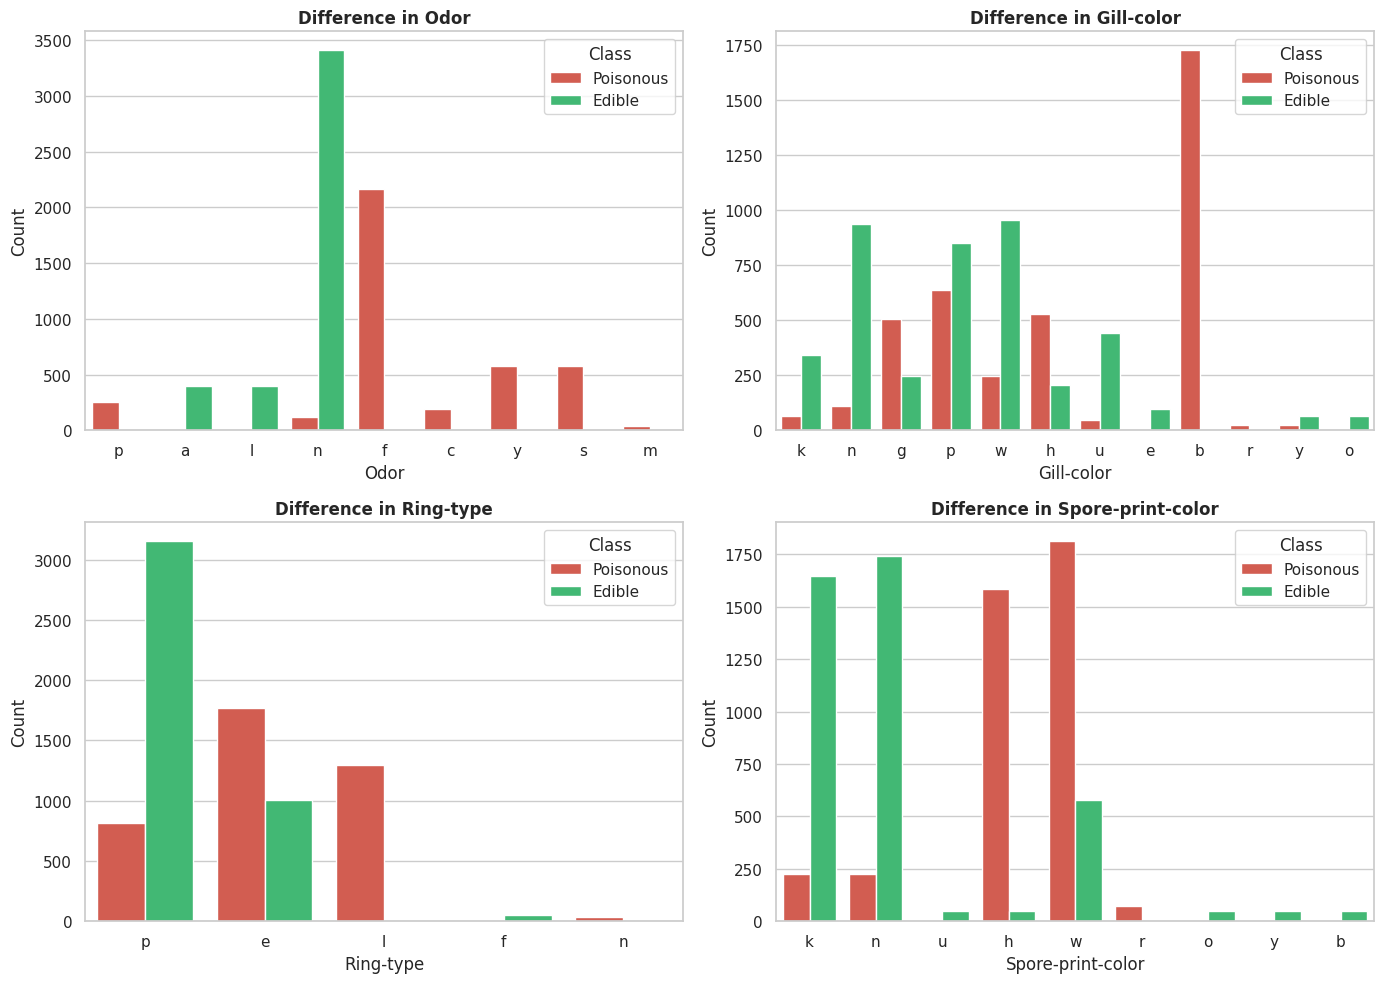

In [5]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download and load dataset
path = kagglehub.dataset_download("uciml/mushroom-classification")
df = pd.read_csv(os.path.join(path, "mushrooms.csv"))

# Map labels for readability
df['class'] = df['class'].map({'e': 'Edible', 'p': 'Poisonous'})

# 2. Select key physical features to compare
features_to_plot = ['odor', 'gill-color', 'ring-type', 'spore-print-color']

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 3. Plot distribution differences for each feature
for idx, feature in enumerate(features_to_plot):
    sns.countplot(
        data=df,
        x=feature,
        hue='class',
        ax=axes[idx],
        palette={'Edible': '#2ecc71', 'Poisonous': '#e74c3c'}
    )
    axes[idx].set_title(f'Difference in {feature.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature.capitalize())
    axes[idx].set_ylabel('Count')
    axes[idx].legend(title='Class')

plt.tight_layout()
plt.show()

In [7]:
import os
import kagglehub
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Download & Load Dataset
path = kagglehub.dataset_download("uciml/mushroom-classification")
df = pd.read_csv(os.path.join(path, "mushrooms.csv"))

# 2. Extract Morphological Features Critical for Taxonomy
taxa_features = [
    'cap-shape', 'cap-surface', 'gill-attachment', 'gill-color',
    'stalk-shape', 'stalk-root', 'ring-type', 'spore-print-color', 'habitat'
]
X_raw = df[taxa_features]

# One-hot encode categorical traits
encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X_raw)

# 3. Unsupervised Taxa Discovery (Clustering into 5 Morphive Taxa Groups)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Taxonomic_Cluster'] = kmeans.fit_predict(X_encoded)

print("--- Taxonomic Distribution across Clusters ---")
print(df['Taxonomic_Cluster'].value_counts())

# 4. Map Spore Print Colors to Approximate Fungal Genera / Families
spore_taxa_map = {
    'k': 'Agaricaceae (Black Spored)',
    'n': 'Agaricaceae (Brown Spored)',
    'b': 'Coprinaceae (Buff Spored)',
    'h': 'Bolbitiaceae (Chocolate Spored)',
    'w': 'Amanitaceae / Lepiotaceae (White Spored)',
    'r': 'Strophariaceae (Green Spored)',
    'o': 'Cortinariaceae (Orange Spored)',
    'u': 'Entolomataceae (Purple Spored)',
    'y': 'Russulaceae (Yellow Spored)'
}

df['Estimated_Taxa_Family'] = df['spore-print-color'].map(spore_taxa_map)

# 5. Build Supervised Classifier to Predict Taxa Family from Physical Features
X = X_encoded
y = df['Estimated_Taxa_Family']

# FIX: Changed test_state=42 to random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate Classification
y_pred = clf.predict(X_test)
print("\n--- Taxonomic Family Classification Report ---")
print(classification_report(y_test, y_pred))

Using Colab cache for faster access to the 'mushroom-classification' dataset.
--- Taxonomic Distribution across Clusters ---
Taxonomic_Cluster
0    2281
1    1952
2    1779
3    1344
4     768
Name: count, dtype: int64

--- Taxonomic Family Classification Report ---
                                          precision    recall  f1-score   support

              Agaricaceae (Black Spored)       1.00      1.00      1.00       373
              Agaricaceae (Brown Spored)       1.00      1.00      1.00       404
Amanitaceae / Lepiotaceae (White Spored)       1.00      1.00      1.00       452
         Bolbitiaceae (Chocolate Spored)       1.00      1.00      1.00       338
               Coprinaceae (Buff Spored)       1.00      1.00      1.00         8
          Cortinariaceae (Orange Spored)       1.00      1.00      1.00         9
          Entolomataceae (Purple Spored)       1.00      1.00      1.00        14
             Russulaceae (Yellow Spored)       1.00      1.00      1.00     

Using Colab cache for faster access to the 'mushroom-classification' dataset.


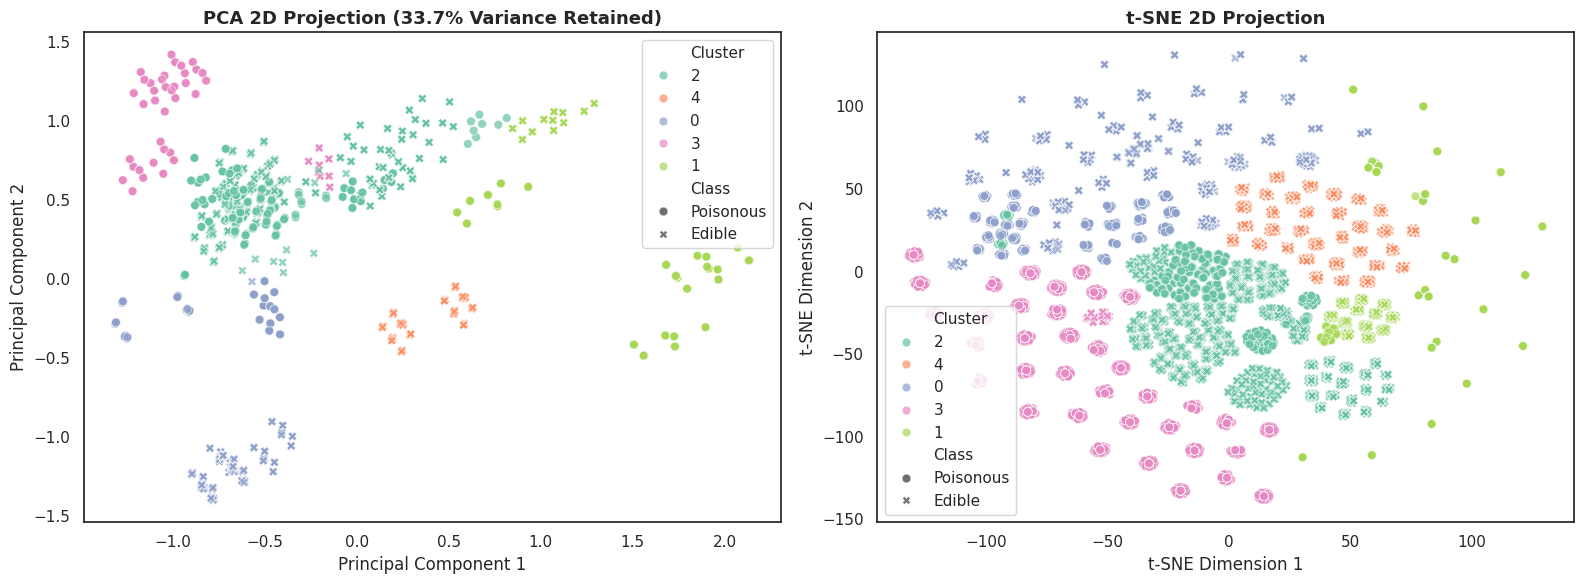

In [8]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Download and load the dataset
path = kagglehub.dataset_download("uciml/mushroom-classification")
df = pd.read_csv(os.path.join(path, "mushrooms.csv"))

# 2. Select taxonomic morphological traits and one-hot encode
taxa_features = [
    'cap-shape', 'cap-surface', 'gill-attachment', 'gill-color',
    'stalk-shape', 'stalk-root', 'ring-type', 'spore-print-color', 'habitat'
]
X_raw = df[taxa_features]

encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X_raw)

# 3. Discover clusters via K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_encoded).astype(str)
df['Class'] = df['class'].map({'e': 'Edible', 'p': 'Poisonous'})

# 4. Dimensionality Reduction
# PCA (Linear)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_encoded)
df['PCA1'], df['PCA2'] = X_pca[:, 0], X_pca[:, 1]

# t-SNE (Non-Linear Manifold)
tsne = TSNE(n_components=2, perplexity=35, random_state=42, learning_rate='auto')
X_tsne = tsne.fit_transform(X_encoded)
df['tSNE1'], df['tSNE2'] = X_tsne[:, 0], X_tsne[:, 1]

# 5. Plot Side-by-Side Projections
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PCA Projection
sns.scatterplot(
    data=df, x='PCA1', y='PCA2', hue='Cluster', style='Class',
    palette='Set2', alpha=0.7, s=40, ax=axes[0]
)
var_exp = pca.explained_variance_ratio_.sum() * 100
axes[0].set_title(f'PCA 2D Projection ({var_exp:.1f}% Variance Retained)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Plot 2: t-SNE Projection
sns.scatterplot(
    data=df, x='tSNE1', y='tSNE2', hue='Cluster', style='Class',
    palette='Set2', alpha=0.7, s=40, ax=axes[1]
)
axes[1].set_title('t-SNE 2D Projection', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.show()